# Part B: Reimplementation
## Methodological reproduction of Khmaissia et al. (2020) using Greater Sydney POAs

This notebook reproduces the core machine learning algorithm workflow from **Khmaissia et al. (2020), “An Unsupervised Machine Learning Approach to Assess the ZIP Code Level Impact of COVID-19 in NYC”**, using publicly available Australian data.

### Study design
- **Study area:** 247 Greater Sydney Postal Areas (POAs), identified from 33 Greater Sydney LGAs in the NSW Health dataset.
- **COVID-19 study period:** **16 June 2021 to 10 October 2021 inclusive** (117 days), representing the pre-reopening Delta period.
- **Candidate predictors:** 28 Census-derived sociodemographic/contextual variables.
- **COVID-19 outcome:** Average Daily Increase Rate (IR), with total cases and cases per 1,000 population retained as secondary outcomes.
- **Feature selection:** LASSO and continuous-target RReliefF; the **union** of selected features is used for clustering.
- **Clustering:** K-means is fitted directly to the selected standardised features.
- **Interpretation:** category-level 1-D t-SNE is performed **after** clustering and is not used as a K-means input.
- **Primary solution:** k = 3, selected using the elbow pattern together with silhouette diagnostics.
- **Sensitivity analysis:** k = 6, matching the number of clusters used in the NYC base paper.

This is a **methodological reproduction using a different public dataset**, not a numerical replication of the original NYC results.


## Public input datasets

The notebook uses three public datasets:

1. **ABS 2021 Census DataPack**: General Community Profile, Postal Areas (POA), New South Wales, short-header ZIP  
   Landing page: https://www.abs.gov.au/census/find-census-data/datapacks  
   Direct file used: `2021_GCP_POA_for_NSW_short-header.zip`

2. **NSW Health COVID-19 cases by location**: Case-level data by notification date and postcode  
   Landing page: https://data.nsw.gov.au/data/dataset/covid-19-cases-by-location  
   Direct file used: `confirmed_cases_table1_location.csv`

3. **ABS 2021 Postal Area boundaries**: GDA2020 Shapefile  
   Landing page: https://www.abs.gov.au/statistics/standards/australian-statistical-geography-standard-asgs/edition-3-july-2021-june-2026/access-and-downloads/digital-boundary-files  
   Direct file used: `POA_2021_AUST_GDA2020_SHP.zip`

**Step 2 will attempt to download all three files automatically from the official public sources.**  



## Step 1: Import libraries

In [2]:
import os
import re
import json
import glob
import shutil
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import joblib

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

from scipy.stats import f_oneway, kruskal

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

# Consistent cluster colours used throughout figures
CLUSTER_COLORS = {
    0: "#3B6FB6",  # muted blue
    1: "#7A7A7A",  # neutral grey
    2: "#2E8B7D"   # muted teal
}

print("Environment ready.")


Environment ready.


## Step 2: Retrieve the three public input datasets

This cell creates a local project folder inside the Colab runtime and downloads the three required public datasets from their official sources.



In [3]:
# Local project folders inside the current Colab runtime
project_dir = "/content/Data_Science_Reproduction_Part_B"
raw_dir = os.path.join(project_dir, "raw_data")
checkpoint_dir = os.path.join(project_dir, "results")
output_dir = os.path.join(project_dir, "submission_outputs")
figure_dir = os.path.join(output_dir, "figures")
model_dir = os.path.join(output_dir, "models")

for directory in [raw_dir, checkpoint_dir, output_dir, figure_dir, model_dir]:
    os.makedirs(directory, exist_ok=True)

# Official public source files used in this reproduction
DATA_URLS = {
    "confirmed_cases_table1_location.csv":
        "https://data.nsw.gov.au/data/dataset/aefcde60-3b0c-4bc0-9af1-6fe652944ec2/"
        "resource/21304414-1ff1-4243-a5d2-f52778048b29/download/"
        "confirmed_cases_table1_location.csv",

    "2021_GCP_POA_for_NSW_short-header.zip":
        "https://www.abs.gov.au/census/find-census-data/datapacks/download/"
        "2021_GCP_POA_for_NSW_short-header.zip",

    "POA_2021_AUST_GDA2020_SHP.zip":
        "https://www.abs.gov.au/statistics/standards/"
        "australian-statistical-geography-standard-asgs/"
        "edition-3-july-2021-june-2026/access-and-downloads/"
        "digital-boundary-files/POA_2021_AUST_GDA2020_SHP.zip",
}

expected_paths = {
    name: os.path.join(raw_dir, name)
    for name in DATA_URLS
}


def download_public_file(url, destination):
    """Download a public source file with a browser-like user agent."""
    request = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(request, timeout=300) as response:
        with open(destination, "wb") as output_file:
            shutil.copyfileobj(response, output_file)


def identify_input_files(search_roots):
    """
    Identify the three required datasets by file contents rather than
    relying only on filenames.
    """
    covid = None
    census = None
    boundary = None

    candidate_files = []
    for root in search_roots:
        candidate_files.extend(
            p for p in glob.glob(os.path.join(root, "*"))
            if os.path.isfile(p)
        )

    for path in candidate_files:

        if path.lower().endswith(".csv"):
            try:
                sample = pd.read_csv(path, nrows=5)
                required_columns = {
                    "notification_date",
                    "postcode",
                    "lga_name19"
                }
                if required_columns.issubset(sample.columns):
                    covid = path
            except Exception:
                pass

        elif path.lower().endswith(".zip"):
            try:
                with zipfile.ZipFile(path) as archive:
                    members = archive.namelist()

                if any(
                    os.path.basename(member) == "2021Census_G01_NSW_POA.csv"
                    for member in members
                ):
                    census = path

                if any(
                    os.path.basename(member).lower().startswith("poa_2021_aust_gda2020")
                    and member.lower().endswith(".shp")
                    for member in members
                ):
                    boundary = path

            except zipfile.BadZipFile:
                pass

    return covid, census, boundary


# Attempt automatic download of any missing official files
download_failures = []

for filename, url in DATA_URLS.items():
    destination = expected_paths[filename]

    if os.path.exists(destination) and os.path.getsize(destination) > 0:
        print("Already present:", filename)
        continue

    print("Downloading:", filename)

    try:
        download_public_file(url, destination)
        print("  saved:", destination)

    except Exception as exc:
        download_failures.append((filename, str(exc)))
        if os.path.exists(destination):
            os.remove(destination)
        print("  automatic download failed:", filename)


# Manual upload fallback if required
covid_file, census_zip_file, boundary_file = identify_input_files(
    [raw_dir, "/content"]
)

if any(path is None for path in [covid_file, census_zip_file, boundary_file]):
    print("\nOne or more files were not downloaded automatically.")
    print("Please upload the three public source files when prompted.")

    from google.colab import files
    uploaded = files.upload()

    for name, content in uploaded.items():
        uploaded_path = os.path.join("/content", name)
        if not os.path.exists(uploaded_path):
            with open(uploaded_path, "wb") as file:
                file.write(content)

    covid_file, census_zip_file, boundary_file = identify_input_files(
        [raw_dir, "/content"]
    )


# Final validation
required_inputs = {
    "NSW COVID-19 case data": covid_file,
    "ABS Census DataPack": census_zip_file,
    "ABS POA boundary shapefile": boundary_file,
}

missing_inputs = [
    name for name, path in required_inputs.items()
    if path is None
]

if missing_inputs:
    raise FileNotFoundError(
        "Could not identify the following required input dataset(s): "
        + ", ".join(missing_inputs)
        + ". Download the public files listed above, upload them into Colab, "
          "and rerun Step 2."
    )

print("\nAll required public datasets identified successfully:")
print("COVID-19 data:", covid_file)
print("Census DataPack:", census_zip_file)
print("POA boundaries:", boundary_file)
print("\nProject directory:", project_dir)


Downloading: confirmed_cases_table1_location.csv
  saved: /content/Data_Science_Reproduction_Part_B/raw_data/confirmed_cases_table1_location.csv
Downloading: 2021_GCP_POA_for_NSW_short-header.zip
  saved: /content/Data_Science_Reproduction_Part_B/raw_data/2021_GCP_POA_for_NSW_short-header.zip
Downloading: POA_2021_AUST_GDA2020_SHP.zip
  saved: /content/Data_Science_Reproduction_Part_B/raw_data/POA_2021_AUST_GDA2020_SHP.zip

All required public datasets identified successfully:
COVID-19 data: /content/Data_Science_Reproduction_Part_B/raw_data/confirmed_cases_table1_location.csv
Census DataPack: /content/Data_Science_Reproduction_Part_B/raw_data/2021_GCP_POA_for_NSW_short-header.zip
POA boundaries: /content/Data_Science_Reproduction_Part_B/raw_data/POA_2021_AUST_GDA2020_SHP.zip

Project directory: /content/Data_Science_Reproduction_Part_B


## Step 3: Load and inspect the NSW Health COVID-19 data

In [4]:
covid = pd.read_csv(covid_file)

print("COVID dataset shape:", covid.shape)
print("Columns:", covid.columns.tolist())
covid.head()

COVID dataset shape: (973412, 6)
Columns: ['notification_date', 'postcode', 'lhd_2010_code', 'lhd_2010_name', 'lga_code19', 'lga_name19']


,notification_date,postcode,lhd_2010_code,lhd_2010_name,lga_code19,lga_name19
0,2020-01-25,2134.0,X700,Sydney,11300,Burwood (A)
1,2020-01-25,2121.0,X760,Northern Sydney,16260,Parramatta (C)
2,2020-01-25,2071.0,X760,Northern Sydney,14500,Ku-ring-gai (A)
3,2020-01-27,2033.0,X720,South Eastern Sydney,16550,Randwick (C)
4,2020-03-01,2077.0,X760,Northern Sydney,14000,Hornsby (A)


## Step 4: Clean notification date and postcode

In [5]:
covid["notification_date"] = pd.to_datetime(
    covid["notification_date"],
    errors="coerce"
)

covid["postcode"] = pd.to_numeric(
    covid["postcode"],
    errors="coerce"
).astype("Int64")

print("Date range:", covid["notification_date"].min(), "to", covid["notification_date"].max())
print("Missing postcode rows:", covid["postcode"].isna().sum())

Date range: 2020-01-25 00:00:00 to 2022-02-07 00:00:00
Missing postcode rows: 13544


## Step 5: Define the agreed Greater Sydney LGAs

In [6]:
greater_sydney_lgas = [
    "Bayside (A)",
    "Blacktown (C)",
    "Blue Mountains (C)",
    "Burwood (A)",
    "Camden (A)",
    "Campbelltown (C) (NSW)",
    "Canada Bay (A)",
    "Canterbury-Bankstown (A)",
    "Cumberland (A)",
    "Fairfield (C)",
    "Georges River (A)",
    "Hawkesbury (C)",
    "Hornsby (A)",
    "Hunters Hill (A)",
    "Inner West (A)",
    "Ku-ring-gai (A)",
    "Lane Cove (A)",
    "Liverpool (C)",
    "Mosman (A)",
    "North Sydney (A)",
    "Northern Beaches (A)",
    "Parramatta (C)",
    "Penrith (C)",
    "Randwick (C)",
    "Ryde (C)",
    "Strathfield (A)",
    "Sutherland Shire (A)",
    "Sydney (C)",
    "The Hills Shire (A)",
    "Waverley (A)",
    "Willoughby (C)",
    "Wollondilly (A)",
    "Woollahra (A)"
]

print("Number of LGAs:", len(greater_sydney_lgas))

Number of LGAs: 33


## Step 6: Create the fixed Greater Sydney POA cohort
The full NSW Health dataset is used to identify postcodes associated with the predefined 33 Greater Sydney LGAs. This keeps the POA cohort independent of the selected COVID-19 study window.


In [7]:
covid_sydney = covid[
    covid["lga_name19"].isin(greater_sydney_lgas)
].copy()

sydney_postcodes = sorted(
    covid_sydney["postcode"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

print("Greater Sydney POAs:", len(sydney_postcodes))
print("First 10:", sydney_postcodes[:10])

if len(sydney_postcodes) != 247:
    print("WARNING: expected 247 POAs for the predefined Greater Sydney cohort. Review the source data before continuing.")

pd.DataFrame({"postcode": sydney_postcodes}).to_csv(
    os.path.join(checkpoint_dir, "greater_sydney_postcodes.csv"),
    index=False
)

Greater Sydney POAs: 247
First 10: [2000, 2007, 2008, 2009, 2010, 2011, 2015, 2016, 2017, 2018]


## Step 7: Set the final COVID-19 study period

In [8]:
start_date = "2021-06-16"
end_date = "2021-10-10"
all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
n_days = len(all_dates)

covid_period = covid_sydney[
    (covid_sydney["notification_date"] >= start_date) &
    (covid_sydney["notification_date"] <= end_date)
].copy()

print("Study period:", start_date, "to", end_date)
print("Number of calendar days:", n_days)
print("Case-level records in Greater Sydney during period:", len(covid_period))

Study period: 2021-06-16 to 2021-10-10
Number of calendar days: 117
Case-level records in Greater Sydney during period: 55428


## Step 8: Build a complete postcode × date grid
Every one of the 247 POAs receives every date in the 117-day window. Days with no notified cases therefore count as **zero**, not missing.

In [9]:
daily_cases = (
    covid_period
    .dropna(subset=["postcode"])
    .groupby(["postcode", "notification_date"])
    .size()
    .reset_index(name="new_cases")
)

full_index = pd.MultiIndex.from_product(
    [sydney_postcodes, all_dates],
    names=["postcode", "notification_date"]
)

daily_cases = (
    daily_cases
    .set_index(["postcode", "notification_date"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print("Daily grid shape:", daily_cases.shape)
print("Expected:", len(sydney_postcodes) * n_days, "rows")
daily_cases.head()

Daily grid shape: (28899, 3)
Expected: 28899 rows


,postcode,notification_date,new_cases
0,2000,2021-06-16,0
1,2000,2021-06-17,0
2,2000,2021-06-18,0
3,2000,2021-06-19,0
4,2000,2021-06-20,0


## Step 9: Calculate COVID-19 Increase Rate (IR)
For each postcode, calculate consecutive changes in daily new cases and divide the summed changes by the **number of calendar days** in the study window.

**Important limitation:** this expression telescopes. It is therefore strongly influenced by the difference between the first and final daily case counts. We keep it for methodological fidelity to Khmassia et al. (2020) and retain cases per 1,000 as a secondary outcome.

In [10]:
daily_cases["daily_change"] = (
    daily_cases
    .groupby("postcode")["new_cases"]
    .diff()
)

covid_ir = (
    daily_cases
    .groupby("postcode")["daily_change"]
    .sum()
    .div(n_days)
    .reset_index(name="covid_IR")
)

covid_by_postcode = (
    covid_period
    .dropna(subset=["postcode"])
    .groupby("postcode")
    .size()
    .reset_index(name="covid_cases")
)

covid_outcomes = covid_ir.merge(
    covid_by_postcode,
    on="postcode",
    how="left"
)

covid_outcomes["covid_cases"] = covid_outcomes["covid_cases"].fillna(0).astype(int)

print("COVID outcome rows:", len(covid_outcomes))
print("IR range:", covid_outcomes["covid_IR"].min(), "to", covid_outcomes["covid_IR"].max())
print("Postcodes with IR exactly 0:", (covid_outcomes["covid_IR"] == 0).sum())
covid_outcomes.head()

COVID outcome rows: 247
IR range: -0.008547008547008548 to 0.17094017094017094
Postcodes with IR exactly 0: 158


,postcode,covid_IR,covid_cases
0,2000,0.008547,194
1,2007,0.000000,37
2,2008,0.000000,47
3,2009,0.000000,71
4,2010,0.000000,241


## Step 10: Load ABS 2021 Postal Area boundaries
The boundary table provides `AREASQKM21`, which lets us calculate **population density**, and the geometry needed for maps later.

In [11]:
poa_boundaries = gpd.read_file(f"zip://{boundary_file}")

poa_boundaries["postcode"] = pd.to_numeric(
    poa_boundaries["POA_CODE21"],
    errors="coerce"
).astype("Int64")

sydney_boundaries = poa_boundaries[
    poa_boundaries["postcode"].isin(sydney_postcodes)
].copy()

print("Australian POAs in shapefile:", len(poa_boundaries))
print("Greater Sydney POA polygons:", len(sydney_boundaries))
print("Missing geometries:", sydney_boundaries["geometry"].isna().sum())

if len(sydney_boundaries) != len(sydney_postcodes):
    print("WARNING: boundary count does not match the fixed Sydney POA cohort.")

Australian POAs in shapefile: 2644
Greater Sydney POA polygons: 247
Missing geometries: 0


## Step 11: Helper function to load ABS Census tables

In [12]:
def load_abs_table(table_code):
    """
    Load one ABS General Community Profile table from the Census ZIP.
    The archive member is located by basename so the code does not depend
    on the ZIP's internal folder name.
    """
    expected_filename = f"2021Census_{table_code}_NSW_POA.csv"

    with zipfile.ZipFile(census_zip_file) as archive:
        matches = [
            member for member in archive.namelist()
            if os.path.basename(member) == expected_filename
        ]

        if len(matches) != 1:
            raise FileNotFoundError(
                f"Expected one {expected_filename} inside the Census ZIP; "
                f"found {len(matches)}."
            )

        with archive.open(matches[0]) as file:
            df = pd.read_csv(file)

    df["postcode"] = pd.to_numeric(
        df["POA_CODE_2021"]
        .astype(str)
        .str.extract(r"(\d{4})")[0],
        errors="coerce"
    ).astype("Int64")

    return df[df["postcode"].isin(sydney_postcodes)].copy()


def safe_pct(numerator, denominator):
    """Return percentage, using NaN when denominator is zero."""
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    return np.where(
        denominator > 0,
        (numerator / denominator) * 100,
        np.nan
    )


## Step 12: Load the Census tables needed for the 28 candidate predictors

In [13]:
g01 = load_abs_table("G01")   # age, sex, cultural background, school completion
g02 = load_abs_table("G02")   # medians and averages
g29 = load_abs_table("G29")   # one-parent families
g31 = load_abs_table("G31")   # intact families
g34 = load_abs_table("G34")   # vehicles
g35 = load_abs_table("G35")   # household size distribution
g37 = load_abs_table("G37")   # dwelling structure and tenure
g43 = load_abs_table("G43")   # labour force and tertiary qualifications
g62 = load_abs_table("G62")   # method of travel to work

for name, df in {
    "G01": g01, "G02": g02, "G29": g29, "G31": g31,
    "G34": g34, "G35": g35, "G37": g37, "G43": g43, "G62": g62
}.items():
    print(name, df.shape)

G01 (247, 110)
G02 (247, 10)
G29 (247, 48)
G31 (247, 10)
G34 (247, 10)
G35 (247, 23)
G37 (247, 74)
G43 (247, 68)
G62 (247, 110)


# 28 feature candidate dictionary
The candidate set is frozen **before** feature selection. Variables were chosen to represent the original paper's conceptual domains while avoiding excessive duplication.

Nine domains:
1. Age & gender
2. Cultural background (Australian contextual proxy for the paper's race category)
3. Education
4. Family
5. Income
6. Occupation/labour force
7. Household/housing
8. Mobility
9. General demographics

Percentages are engineered transparently from ABS counts. `population` is retained for cases per 1,000 but is **not** a K-means predictor; `population_density` is used instead.

## Step 13: Age, gender, cultural background, and Year 12 completion

In [14]:
features = pd.DataFrame({
    "postcode": g01["postcode"].astype("Int64"),
    "population": g01["Tot_P_P"]
})

features["pct_female"] = safe_pct(
    g01["Tot_P_F"],
    g01["Tot_P_P"]
)

features["pct_age_0_19"] = safe_pct(
    g01[["Age_0_4_yr_P", "Age_5_14_yr_P", "Age_15_19_yr_P"]].sum(axis=1),
    g01["Tot_P_P"]
)

features["pct_age_65_plus"] = safe_pct(
    g01[["Age_65_74_yr_P", "Age_75_84_yr_P", "Age_85ov_P"]].sum(axis=1),
    g01["Tot_P_P"]
)

features["pct_indigenous"] = safe_pct(
    g01["Indigenous_P_Tot_P"],
    g01["Tot_P_P"]
)

features["pct_born_overseas"] = safe_pct(
    g01["Birthplace_Elsewhere_P"],
    g01["Tot_P_P"]
)

features["pct_other_language_home"] = safe_pct(
    g01["Lang_used_home_Oth_Lang_P"],
    g01["Tot_P_P"]
)

school_completion_denominator = g01[[
    "High_yr_schl_comp_Yr_12_eq_P",
    "High_yr_schl_comp_Yr_11_eq_P",
    "High_yr_schl_comp_Yr_10_eq_P",
    "High_yr_schl_comp_Yr_9_eq_P",
    "High_yr_schl_comp_Yr_8_belw_P",
    "High_yr_schl_comp_D_n_g_sch_P"
]].sum(axis=1)

features["pct_year12_completion"] = safe_pct(
    g01["High_yr_schl_comp_Yr_12_eq_P"],
    school_completion_denominator
)

print("Shape after Step 13:", features.shape)

Shape after Step 13: (247, 9)


## Step 14: Age median, income, household averages, rent and mortgage

In [15]:
g02_keep = g02[[
    "postcode",
    "Median_age_persons",
    "Median_tot_prsnl_inc_weekly",
    "Median_tot_hhd_inc_weekly",
    "Average_household_size",
    "Average_num_psns_per_bedroom",
    "Median_rent_weekly",
    "Median_mortgage_repay_monthly"
]].copy()

g02_keep = g02_keep.rename(columns={
    "Median_age_persons": "median_age_persons",
    "Median_tot_prsnl_inc_weekly": "median_personal_income",
    "Median_tot_hhd_inc_weekly": "median_household_income",
    "Average_household_size": "avg_household_size",
    "Average_num_psns_per_bedroom": "avg_persons_per_bedroom",
    "Median_rent_weekly": "median_rent_weekly",
    "Median_mortgage_repay_monthly": "median_mortgage_repay_monthly"
})

features = features.merge(g02_keep, on="postcode", how="left")
print("Shape after Step 14:", features.shape)

Shape after Step 14: (247, 16)


## Step 15: Education and labour-force variables

In [16]:
bachelor_or_higher_count = (
    g43["non_sch_qual_PostGrad_Dgre_P"] +
    g43["non_sch_qual_Gr_Dip_Gr_Crt_P"] +
    g43["non_sch_qual_Bchelr_Degree_P"]
)

g43_features = pd.DataFrame({
    "postcode": g43["postcode"],
    "pct_bachelor_or_higher": safe_pct(
        bachelor_or_higher_count,
        g43["P_15_yrs_over_P"]
    ),
    "unemployment_rate": g43["Percent_Unem_loyment_P"],
    "labour_force_participation": g43["Percnt_LabForc_prticipation_P"]
})

features = features.merge(g43_features, on="postcode", how="left")
print("Shape after Step 15:", features.shape)

Shape after Step 15: (247, 19)


## Step 16: Family structure

In [17]:
one_parent = pd.DataFrame({
    "postcode": g29["postcode"],
    "pct_one_parent_families": safe_pct(
        g29["OPF_Total_F"],
        g29["Total_F"]
    )
})

intact_family_count = (
    g31["Intct_fam_no_otr_chld_pre_Fam"] +
    g31["Intct_fam_othr_child_pres_Fam"]
)

intact = pd.DataFrame({
    "postcode": g31["postcode"],
    "intact_family_pct": safe_pct(
        intact_family_count,
        g31["Tot_Families"]
    )
})

features = features.merge(one_parent, on="postcode", how="left")
features = features.merge(intact, on="postcode", how="left")

print("Shape after Step 16:", features.shape)

Shape after Step 16: (247, 21)


## Step 17: Household and housing structure

In [18]:
household_features = pd.DataFrame({
    "postcode": g35["postcode"],
    "pct_lone_person_household": safe_pct(
        g35["Num_Psns_UR_1_Total"],
        g35["Total_Total"]
    )
})

housing_features = pd.DataFrame({
    "postcode": g37["postcode"],
    "flat_apartment_pct": safe_pct(
        g37["Total_DS_Flat_apart"],
        g37["Total_Total"]
    ),
    "rented_pct": safe_pct(
        g37["R_Tot_Total"],
        g37["Total_Total"]
    )
})

features = features.merge(household_features, on="postcode", how="left")
features = features.merge(housing_features, on="postcode", how="left")

print("Shape after Step 17:", features.shape)

Shape after Step 17: (247, 24)


## Step 18: Vehicle availability

In [19]:
vehicle_denominator = g34["Num_MVs_per_dweling_Tot"]

two_plus_vehicles = g34[[
    "Num_MVs_per_dweling_2_MVs",
    "Num_MVs_per_dweling_3_MVs",
    "Num_MVs_per_dweling_4mo_MVs"
]].sum(axis=1)

vehicle_features = pd.DataFrame({
    "postcode": g34["postcode"],
    "pct_zero_vehicle_dwellings": safe_pct(
        g34["Num_MVs_per_dweling_0_MVs"],
        vehicle_denominator
    ),
    "pct_2plus_vehicle_dwellings": safe_pct(
        two_plus_vehicles,
        vehicle_denominator
    )
})

features = features.merge(vehicle_features, on="postcode", how="left")
print("Shape after Step 18:", features.shape)

Shape after Step 18: (247, 26)


## Step 19: Mobility proxies from method of travel to work
These variables are Australian substitutes for the NYC paper's subway/CitiBike mobility data.

- `pct_train_commute`: proportion of the G62 employed-person denominator whose journey included train.
- `pct_public_transport_commute`: conservative union of explicitly identified train/bus/ferry/light-rail categories, avoiding double-counting train+bus combinations.
- `pct_work_from_home`: proportion recorded as working at home.

**Limitation:** the 2021 Census was conducted during COVID restrictions in Sydney, so these variables describe Census-day travel/work patterns rather than normal pre-pandemic mobility.

In [20]:
train_commute_count = (
    g62["One_method_Train_P"] +
    g62["Two_methods_Train_Tot_P"] +
    g62["Three_meth_Tr_2_oth_meth_P"]
)

public_transport_count = (
    g62["One_method_Train_P"] +
    g62["One_method_Bus_P"] +
    g62["One_method_Ferry_P"] +
    g62["One_met_Tram_or_lt_rail_P"] +
    g62["Two_methods_Train_Tot_P"] +
    g62["Two_methods_Bus_Ferry_P"] +
    g62["Two_mth_Bu_Trm_or_lt_rail_P"] +
    g62["Two_methods_Bus_Car_as_drvr_P"] +
    g62["Two_methods_Bus_Car_as_pass_P"] +
    g62["Two_methods_Bus_Other_P"] +
    g62["Three_meth_Tr_2_oth_meth_P"] +
    g62["Three_met_Bs_2_ot_met_ex_tr_P"]
)

mobility_features = pd.DataFrame({
    "postcode": g62["postcode"],
    "pct_train_commute": safe_pct(
        train_commute_count,
        g62["Tot_P"]
    ),
    "pct_public_transport_commute": safe_pct(
        public_transport_count,
        g62["Tot_P"]
    ),
    "pct_work_from_home": safe_pct(
        g62["Worked_home_P"],
        g62["Tot_P"]
    )
})

features = features.merge(mobility_features, on="postcode", how="left")
print("Shape after Step 19:", features.shape)

Shape after Step 19: (247, 29)


## Step 20: Population density and the final 28 feature list

In [21]:
area_lookup = sydney_boundaries[["postcode", "AREASQKM21"]].copy()
area_lookup = area_lookup.rename(columns={"AREASQKM21": "area_sq_km"})

features = features.merge(area_lookup, on="postcode", how="left")
features["population_density"] = (
    features["population"] / features["area_sq_km"]
)

FINAL_FEATURES = [
    # Age & gender (4)
    "pct_female",
    "pct_age_0_19",
    "pct_age_65_plus",
    "median_age_persons",

    # Cultural background (3)
    "pct_indigenous",
    "pct_born_overseas",
    "pct_other_language_home",

    # Education (2)
    "pct_year12_completion",
    "pct_bachelor_or_higher",

    # Family (2)
    "pct_one_parent_families",
    "intact_family_pct",

    # Income (2)
    "median_personal_income",
    "median_household_income",

    # Occupation / labour force (2)
    "unemployment_rate",
    "labour_force_participation",

    # Household / housing (7)
    "avg_household_size",
    "avg_persons_per_bedroom",
    "pct_lone_person_household",
    "median_rent_weekly",
    "median_mortgage_repay_monthly",
    "flat_apartment_pct",
    "rented_pct",

    # Mobility (5)
    "pct_zero_vehicle_dwellings",
    "pct_2plus_vehicle_dwellings",
    "pct_train_commute",
    "pct_public_transport_commute",
    "pct_work_from_home",

    # General demographics (1)
    "population_density"
]

FEATURE_GROUPS = {
    "Age_Gender": [
        "pct_female", "pct_age_0_19", "pct_age_65_plus", "median_age_persons"
    ],
    "Cultural_Background": [
        "pct_indigenous", "pct_born_overseas", "pct_other_language_home"
    ],
    "Education": [
        "pct_year12_completion", "pct_bachelor_or_higher"
    ],
    "Family": [
        "pct_one_parent_families", "intact_family_pct"
    ],
    "Income": [
        "median_personal_income", "median_household_income"
    ],
    "Occupation": [
        "unemployment_rate", "labour_force_participation"
    ],
    "Household_Housing": [
        "avg_household_size", "avg_persons_per_bedroom",
        "pct_lone_person_household", "median_rent_weekly",
        "median_mortgage_repay_monthly", "flat_apartment_pct", "rented_pct"
    ],
    "Mobility": [
        "pct_zero_vehicle_dwellings", "pct_2plus_vehicle_dwellings",
        "pct_train_commute", "pct_public_transport_commute", "pct_work_from_home"
    ],
    "General_Demographics": [
        "population_density"
    ]
}

print("Number of final candidate predictors:", len(FINAL_FEATURES))
assert len(FINAL_FEATURES) == 28

Number of final candidate predictors: 28


## Step 21: Merge features with COVID outcomes and run quality checks

In [22]:
shared_input = (
    features[["postcode", "population", "area_sq_km"] + FINAL_FEATURES]
    .merge(covid_outcomes, on="postcode", how="inner")
)

shared_input["covid_cases_per_1000"] = np.where(
    shared_input["population"] > 0,
    (shared_input["covid_cases"] / shared_input["population"]) * 1000,
    np.nan
)

shared_input = shared_input.replace([np.inf, -np.inf], np.nan)

print("Shared input shape:", shared_input.shape)
print("Unique postcodes:", shared_input["postcode"].nunique())
print("Duplicate postcodes:", shared_input["postcode"].duplicated().sum())
print("Total missing values:", shared_input.isna().sum().sum())

missing_by_column = shared_input.isna().sum()
print("\nColumns with missing values:")
print(missing_by_column[missing_by_column > 0])

percentage_columns = [
    c for c in FINAL_FEATURES
    if c.startswith("pct_") or c.endswith("_pct") or c in ["unemployment_rate", "labour_force_participation"]
]

out_of_range = {}
for col in percentage_columns:
    n_bad = ((shared_input[col] < 0) | (shared_input[col] > 100)).sum()
    if n_bad:
        out_of_range[col] = int(n_bad)

print("Percentage variables outside 0–100:", out_of_range if out_of_range else "0 (OK)")

if len(shared_input) != 247:
    print("WARNING: expected 247 rows. Do not continue until the mismatch is understood.")

shared_input.head()

Shared input shape: (247, 34)
Unique postcodes: 247
Duplicate postcodes: 0
Total missing values: 0

Columns with missing values:
Series([], dtype: int64)
Percentage variables outside 0–100: 0 (OK)


,postcode,population,area_sq_km,pct_female,pct_age_0_19,pct_age_65_plus,median_age_persons,pct_indigenous,pct_born_overseas,pct_other_language_home,pct_year12_completion,pct_bachelor_or_higher,pct_one_parent_families,intact_family_pct,median_personal_income,median_household_income,unemployment_rate,labour_force_participation,avg_household_size,avg_persons_per_bedroom,pct_lone_person_household,median_rent_weekly,median_mortgage_repay_monthly,flat_apartment_pct,rented_pct,pct_zero_vehicle_dwellings,pct_2plus_vehicle_dwellings,pct_train_commute,pct_public_transport_commute,pct_work_from_home,population_density,covid_IR,covid_cases,covid_cases_per_1000
0,2000,27936,4.2871,49.087199,7.263030,7.517182,32,0.272050,70.400200,60.355813,88.965460,48.386124,8.127572,88.857413,941,2225,7.2,63.1,2.1,1.3,35.154890,625,2800,96.989210,71.136443,56.552157,7.615033,11.005155,18.253866,39.381443,6516.293065,0.008547,194,6.944444
1,2007,7410,0.5588,49.176788,10.121457,6.342780,30,1.039136,66.167341,57.975709,88.148843,49.538240,11.045219,91.054313,772,1805,9.8,63.3,2.1,1.2,36.602871,500,2500,87.354751,68.147642,48.221489,9.057572,8.112206,14.404852,40.813748,13260.558339,0.000000,37,4.993252
2,2008,10400,0.8450,48.875000,8.634615,4.009615,28,0.971154,56.692308,46.961538,91.749319,54.149565,7.666851,88.927336,860,1746,9.1,63.9,1.9,1.2,43.098160,525,2600,75.701139,72.962314,54.793296,8.916201,7.614126,11.955211,50.094746,12307.692308,0.000000,47,4.519231
3,2009,12658,0.9299,49.510191,12.577026,12.893032,37,1.153421,52.069837,39.903618,85.385204,51.848266,12.156742,89.821029,1297,2422,5.4,67.1,2.1,1.1,32.921368,580,2800,93.730969,61.669353,28.779599,17.613843,2.831760,6.426985,52.415325,13612.216367,0.000000,71,5.609101
4,2010,26443,2.1733,41.909012,6.818440,10.762773,36,0.941648,42.669137,23.643308,87.284144,55.448039,7.763331,89.946524,1479,2297,4.6,71.7,1.7,1.1,48.844809,550,2900,72.693418,63.968688,47.264872,9.644318,4.788914,8.466846,56.180564,12167.211154,0.000000,241,9.113943


## Step 22: Save the final modelling input
This checkpoint contains the 247-POA modelling dataset assembled from the public source data before standardisation and feature selection.


In [23]:
shared_input_path = os.path.join(
    checkpoint_dir,
    "modelling_input_28_features_2021-06-16_to_2021-10-10.csv"
)

shared_input.to_csv(shared_input_path, index=False)
print("Saved modelling input:", shared_input_path)


Saved modelling input: /content/Data_Science_Reproduction_Part_B/results/modelling_input_28_features_2021-06-16_to_2021-10-10.csv


## Step 23: Define X and y, remove constants, and standardise

In [24]:
model_data = shared_input.dropna().copy()

X = model_data[FINAL_FEATURES].copy()
y = model_data["covid_IR"].copy()

non_constant_features = [
    col for col in X.columns
    if X[col].nunique(dropna=True) > 1
]

removed_constants = sorted(set(X.columns) - set(non_constant_features))
X = X[non_constant_features].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Rows used for modelling:", len(model_data))
print("Candidate predictors after constant check:", X.shape[1])
print("Removed constants:", removed_constants if removed_constants else "None")
print("Average standardised mean:", X_scaled.mean().mean())
print("Average standardised SD (ddof=0):", X_scaled.std(ddof=0).mean())

Rows used for modelling: 247
Candidate predictors after constant check: 28
Removed constants: None
Average standardised mean: -1.7176672011985502e-16
Average standardised SD (ddof=0): 1.0


## Step 24: LASSO feature selection
LASSO uses COVID-19 IR as the continuous target during **feature selection**. Five-fold cross-validation selects the regularisation strength. Non-zero coefficients are retained.

This is target-aware feature selection; therefore later comparisons of clusters with IR should not be described as fully independent validation.

In [25]:
lasso = LassoCV(
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=100000
)

lasso.fit(X_scaled, y)

lasso_results = pd.DataFrame({
    "feature": X_scaled.columns,
    "coefficient": lasso.coef_
})

lasso_results["abs_coefficient"] = lasso_results["coefficient"].abs()
lasso_results = lasso_results.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)

lasso_selected = lasso_results.loc[
    lasso_results["abs_coefficient"] > 1e-12,
    "feature"
].tolist()

print("Selected alpha:", lasso.alpha_)
print("LASSO-selected features:", len(lasso_selected))
print(lasso_selected)

lasso_results.head(15)

Selected alpha: 0.0010911375457036564
LASSO-selected features: 6
['unemployment_rate', 'pct_bachelor_or_higher', 'pct_age_0_19', 'median_age_persons', 'labour_force_participation', 'pct_indigenous']


,feature,coefficient,abs_coefficient
0,unemployment_rate,0.006743,0.006743
1,pct_bachelor_or_higher,-0.002816,0.002816
2,pct_age_0_19,0.002705,0.002705
3,median_age_persons,-0.002050,0.002050
4,labour_force_participation,-0.001368,0.001368
5,pct_indigenous,0.000049,0.000049
6,pct_age_65_plus,-0.000000,0.000000
7,pct_female,0.000000,0.000000
8,pct_year12_completion,-0.000000,0.000000
9,pct_one_parent_families,0.000000,0.000000


## Step 25: Load the continuous-target RReliefF implementation

The analysis uses the open-source continuous-target RReliefF implementation from:

- Repository: `https://github.com/AmritSe/RReliefF`
- Source file: `https://raw.githubusercontent.com/AmritSe/RReliefF/master/relieff.py`

This external source code should be cited in the report/code documentation. The original Khmaissia paper does not fully specify its RReliefF selection threshold; this reproduction transparently retains features with **weight > 0**.

The final configuration is `updates="all"`, `k=10`, `sigma=30`.


In [26]:
rrelieff_url = "https://raw.githubusercontent.com/AmritSe/RReliefF/master/relieff.py"
rrelieff_path = "/content/relieff.py"

if not os.path.exists(rrelieff_path):
    urllib.request.urlretrieve(rrelieff_url, rrelieff_path)

from relieff import RReliefF

print("RReliefF implementation loaded from:", rrelieff_url)

RReliefF implementation loaded from: https://raw.githubusercontent.com/AmritSe/RReliefF/master/relieff.py


## Step 26: Run RReliefF and apply the agreed positive-weight threshold

In [27]:
rrelieff_weights = RReliefF(
    X_scaled.to_numpy(),
    y.to_numpy(),
    updates="all",
    k=10,
    sigma=30
).ravel()

rrelieff_results = pd.DataFrame({
    "feature": X_scaled.columns,
    "weight": rrelieff_weights
}).sort_values(
    "weight",
    ascending=False
).reset_index(drop=True)

rrelieff_selected = rrelieff_results.loc[
    rrelieff_results["weight"] > 0,
    "feature"
].tolist()

print("RReliefF-selected features:", len(rrelieff_selected))
print(rrelieff_selected)

rrelieff_results.head(15)

RReliefF-selected features: 16
['unemployment_rate', 'pct_indigenous', 'pct_public_transport_commute', 'pct_one_parent_families', 'pct_train_commute', 'avg_persons_per_bedroom', 'rented_pct', 'pct_born_overseas', 'labour_force_participation', 'pct_year12_completion', 'pct_age_0_19', 'pct_other_language_home', 'avg_household_size', 'pct_female', 'population_density', 'pct_2plus_vehicle_dwellings']


,feature,weight
0,unemployment_rate,0.030083
1,pct_indigenous,0.024963
2,pct_public_transport_commute,0.021797
3,pct_one_parent_families,0.017933
4,pct_train_commute,0.015596
5,avg_persons_per_bedroom,0.011169
6,rented_pct,0.011059
7,pct_born_overseas,0.009578
8,labour_force_participation,0.007108
9,pct_year12_completion,0.006289


## Step 27: Take the union of LASSO and RReliefF selected features

In [28]:
selected_features = sorted(
    set(lasso_selected) | set(rrelieff_selected)
)

overlap = sorted(
    set(lasso_selected) & set(rrelieff_selected)
)

X_selected = X_scaled[selected_features].copy()

print("LASSO selected:", len(lasso_selected))
print("RReliefF selected:", len(rrelieff_selected))
print("Overlap:", len(overlap))
print("UNION used for K-means:", len(selected_features))
print("Selected features:")

for feature in selected_features:
    print(" -", feature)

# Table organised by the conceptual domains used in the reproduction
selected_feature_rows = []

for category, category_features in FEATURE_GROUPS.items():
    retained = [
        feature for feature in category_features
        if feature in selected_features
    ]

    selected_feature_rows.append({
        "feature_category": category.replace("_", " / "),
        "n_selected": len(retained),
        "selected_features": ", ".join(retained) if retained else "None retained"
    })

selected_features_by_domain = pd.DataFrame(selected_feature_rows)

pd.DataFrame({
    "selected_feature": selected_features
}).to_csv(
    os.path.join(checkpoint_dir, "selected_features.csv"),
    index=False
)

selected_features_by_domain.to_csv(
    os.path.join(checkpoint_dir, "selected_features_by_domain.csv"),
    index=False
)

selected_features_by_domain


LASSO selected: 6
RReliefF selected: 16
Overlap: 4
UNION used for K-means: 18
Selected features:
 - avg_household_size
 - avg_persons_per_bedroom
 - labour_force_participation
 - median_age_persons
 - pct_2plus_vehicle_dwellings
 - pct_age_0_19
 - pct_bachelor_or_higher
 - pct_born_overseas
 - pct_female
 - pct_indigenous
 - pct_one_parent_families
 - pct_other_language_home
 - pct_public_transport_commute
 - pct_train_commute
 - pct_year12_completion
 - population_density
 - rented_pct
 - unemployment_rate


,feature_category,n_selected,selected_features
0,Age / Gender,3,"pct_female, pct_age_0_19, median_age_persons"
1,Cultural / Background,3,"pct_indigenous, pct_born_overseas, pct_other_l..."
2,Education,2,"pct_year12_completion, pct_bachelor_or_higher"
3,Family,1,pct_one_parent_families
4,Income,0,None retained
5,Occupation,2,"unemployment_rate, labour_force_participation"
6,Household / Housing,3,"avg_household_size, avg_persons_per_bedroom, r..."
7,Mobility,3,"pct_2plus_vehicle_dwellings, pct_train_commute..."
8,General / Demographics,1,population_density


## Step 28: Evaluate candidate k values with elbow and silhouette diagnostics
The original paper selected `k` using the elbow method. This reproduction evaluates `k = 2` to `10` using both K-means inertia and silhouette coefficient. COVID-19 outcomes are **not** used to select `k`.


In [29]:
k_values = list(range(2, 11))
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = km.fit_predict(X_selected)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_selected, labels)
    )

k_diagnostics = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette": silhouettes
})

print(k_diagnostics)

best_silhouette_k = int(
    k_diagnostics.loc[
        k_diagnostics["silhouette"].idxmax(),
        "k"
    ]
)

best_silhouette_score = float(
    k_diagnostics.loc[
        k_diagnostics["silhouette"].idxmax(),
        "silhouette"
    ]
)

print(
    "\nHighest silhouette:",
    f"k={best_silhouette_k}",
    f"score={best_silhouette_score:.4f}"
)


    k      inertia  silhouette
0   2  3189.076992    0.281897
1   3  2557.578343    0.269483
2   4  2201.602090    0.264663
3   5  1913.455638    0.228916
4   6  1727.298160    0.231629
5   7  1579.401921    0.236984
6   8  1478.224027    0.215437
7   9  1381.438550    0.226097
8  10  1289.327410    0.228776

Highest silhouette: k=2 score=0.2819


## Step 29: Select the primary clustering solution

The silhouette coefficient is highest at `k = 2`, while the elbow curve shows a substantial reduction in inertia up to approximately `k = 3`, followed by progressively smaller improvements. Because the silhouette score at `k = 3` remains close to the maximum and the elbow supports a three-cluster solution, **`PRIMARY_K = 3` is retained for the primary analysis**.


Primary k: 3
Highest-silhouette k: 2
Primary-k silhouette: 0.2695


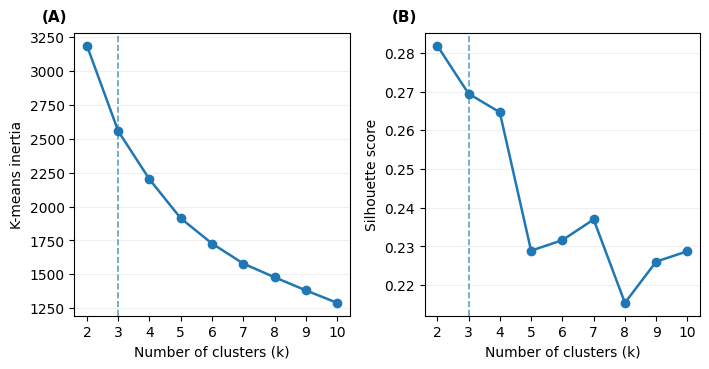

Saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures/k_selection_elbow_silhouette.png


In [30]:
PRIMARY_K = 3

primary_silhouette = float(
    k_diagnostics.loc[
        k_diagnostics["k"] == PRIMARY_K,
        "silhouette"
    ].iloc[0]
)

print("Primary k:", PRIMARY_K)
print("Highest-silhouette k:", best_silhouette_k)
print("Primary-k silhouette:", round(primary_silhouette, 4))

# Combine diagnostic figure
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.8))

# Panel A — elbow
axes[0].plot(
    k_diagnostics["k"],
    k_diagnostics["inertia"],
    marker="o",
    linewidth=1.8
)
axes[0].axvline(
    PRIMARY_K,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("K-means inertia")
axes[0].set_xticks(k_values)
axes[0].text(
    -0.12, 1.04, "(A)",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

# Panel B — silhouette
axes[1].plot(
    k_diagnostics["k"],
    k_diagnostics["silhouette"],
    marker="o",
    linewidth=1.8
)
axes[1].axvline(
    PRIMARY_K,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(k_values)
axes[1].text(
    -0.12, 1.04, "(B)",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold"
)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

k_figure_path = os.path.join(
    figure_dir,
    "k_selection_elbow_silhouette.png"
)

plt.savefig(
    k_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", k_figure_path)


## Step 30: Fit the primary K-means model on the selected features

In [31]:
kmeans = KMeans(
    n_clusters=PRIMARY_K,
    random_state=RANDOM_STATE,
    n_init=20
)

model_data["raw_cluster"] = kmeans.fit_predict(X_selected)

print("Raw cluster sizes:")
print(model_data["raw_cluster"].value_counts().sort_index())

Raw cluster sizes:
raw_cluster
0     75
1    116
2     56
Name: count, dtype: int64


## Step 31: Rank arbitrary K-means labels by mean COVID-19 IR
K-means labels have no inherent order. Following the base paper's logic, raw labels are relabelled so **Cluster 0 has the lowest mean IR** and the highest cluster number has the highest mean IR.

IR is used here **after clustering** to make cluster labels interpretable.

In [32]:
raw_cluster_ir = (
    model_data
    .groupby("raw_cluster")["covid_IR"]
    .mean()
    .sort_values()
)

cluster_mapping = {
    raw_cluster: rank
    for rank, raw_cluster in enumerate(raw_cluster_ir.index)
}

model_data["cluster"] = model_data["raw_cluster"].map(cluster_mapping)

# Ranked cluster IDs used throughout later analyses and figures
cluster_ids = sorted(
    model_data["cluster"].unique()
)

print("Raw-to-ranked cluster mapping:", cluster_mapping)
print("\nMean IR after ranking:")
print(
    model_data
    .groupby("cluster")["covid_IR"]
    .mean()
)


Raw-to-ranked cluster mapping: {0: 0, 1: 1, 2: 2}

Mean IR after ranking:
cluster
0    0.003305
1    0.004568
2    0.029915
Name: covid_IR, dtype: float64


## Step 32: Summarise the primary clusters

In [33]:
cluster_summary = (
    model_data
    .groupby("cluster")
    .agg(
        n_postcodes=("postcode", "count"),
        mean_covid_IR=("covid_IR", "mean"),
        median_covid_IR=("covid_IR", "median"),
        mean_cases=("covid_cases", "mean"),
        median_cases=("covid_cases", "median"),
        mean_cases_per_1000=("covid_cases_per_1000", "mean"),
        median_cases_per_1000=("covid_cases_per_1000", "median")
    )
    .round(4)
)

cluster_summary

,n_postcodes,mean_covid_IR,median_covid_IR,mean_cases,median_cases,mean_cases_per_1000,median_cases_per_1000
cluster,,,,,,,
0,75,0.0033,0.0000,100.7600,66.0,5.0024,4.4194
1,116,0.0046,0.0000,74.9397,27.5,4.1066,2.9234
2,56,0.0299,0.0085,699.6071,480.5,23.3938,18.1018


## Step 33: Reproduce the core cluster-outcome comparison
The original study compared COVID-19 outcome distributions across ranked clusters. Here, IR is shown alongside cases per 1,000 population as a more intuitive secondary measure of COVID-19 burden.


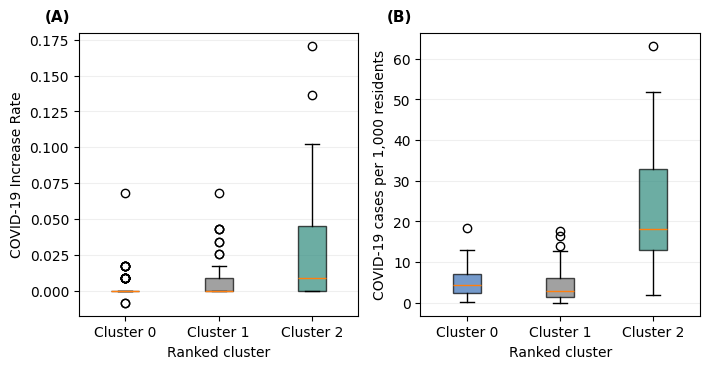

Saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures/cluster_covid_outcomes.png


In [34]:
cluster_order = cluster_ids

ir_groups = [
    model_data.loc[
        model_data["cluster"] == c,
        "covid_IR"
    ].to_numpy()
    for c in cluster_order
]

cases_groups = [
    model_data.loc[
        model_data["cluster"] == c,
        "covid_cases_per_1000"
    ].to_numpy()
    for c in cluster_order
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(7.2, 3.8)
)

# Panel A — IR
bp1 = axes[0].boxplot(
    ir_groups,
    labels=[f"Cluster {c}" for c in cluster_order],
    patch_artist=True
)

for patch, c in zip(bp1["boxes"], cluster_order):
    patch.set_facecolor(CLUSTER_COLORS[c])
    patch.set_alpha(0.7)

axes[0].set_xlabel("Ranked cluster")
axes[0].set_ylabel("COVID-19 Increase Rate")
axes[0].text(
    -0.12, 1.04, "(A)",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold"
)

# Panel B — cases per 1,000
bp2 = axes[1].boxplot(
    cases_groups,
    labels=[f"Cluster {c}" for c in cluster_order],
    patch_artist=True
)

for patch, c in zip(bp2["boxes"], cluster_order):
    patch.set_facecolor(CLUSTER_COLORS[c])
    patch.set_alpha(0.7)

axes[1].set_xlabel("Ranked cluster")
axes[1].set_ylabel("COVID-19 cases per 1,000 residents")
axes[1].text(
    -0.12, 1.04, "(B)",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold"
)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

boxplot_path = os.path.join(
    figure_dir,
    "cluster_covid_outcomes.png"
)

plt.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", boxplot_path)


## Step 34: Exploratory statistical comparison of cluster outcomes
These tests can describe whether the **observed IR distributions differ**, but they are **not independent validation**, because IR was already used in LASSO/RReliefF feature selection and to rank cluster IDs.

In [35]:
ir_cluster_arrays = [
    model_data.loc[model_data["cluster"] == c, "covid_IR"].to_numpy()
    for c in cluster_ids
]

anova_result = f_oneway(*ir_cluster_arrays)
kruskal_result = kruskal(*ir_cluster_arrays)

print("One-way ANOVA on IR:")
print("F =", anova_result.statistic, "p =", anova_result.pvalue)

print("\nKruskal-Wallis on IR:")
print("H =", kruskal_result.statistic, "p =", kruskal_result.pvalue)

One-way ANOVA on IR:
F = 35.27382468302373 p = 3.4979423088008253e-14

Kruskal-Wallis on IR:
H = 48.87906962251003 p = 2.4324554287414145e-11


## Step 35: Cluster feature profile heatmap

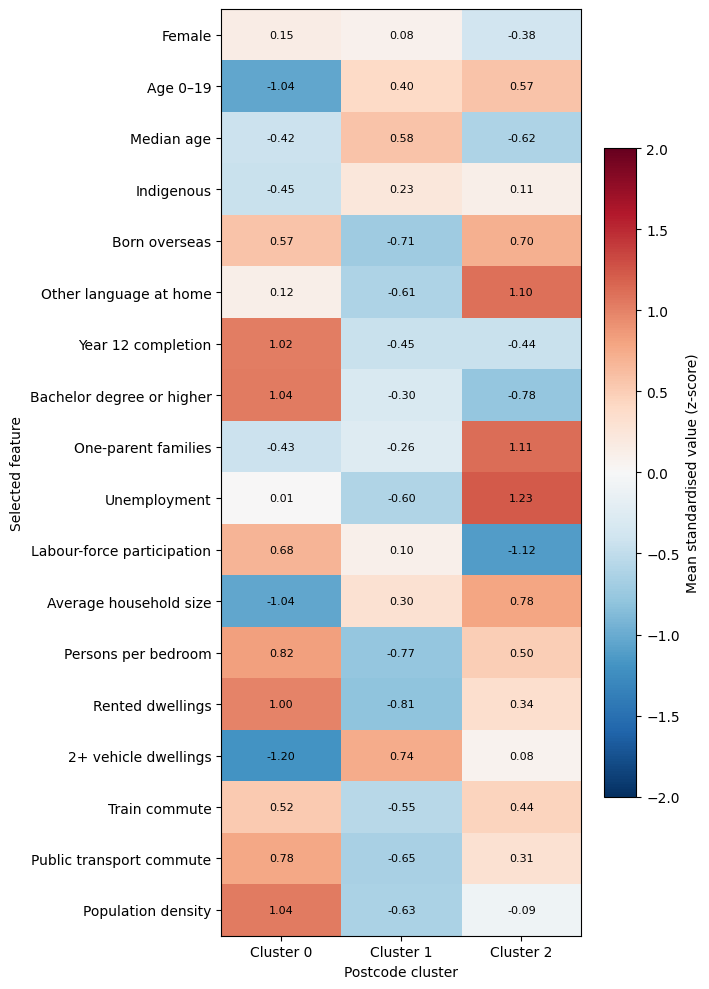

Heatmap saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures/cluster_feature_profile_heatmap.png


In [36]:
# Start from the standardised features actually used in K-means
cluster_profiles_z = X_scaled[selected_features].copy()

# Add the final ranked cluster assignments
cluster_profiles_z["cluster"] = model_data["cluster"].to_numpy()

# Calculate the mean standardised value of each feature within each cluster
cluster_profile_means = (
    cluster_profiles_z
    .groupby("cluster")[selected_features]
    .mean()
)

# Put features into an interpretable order
heatmap_feature_order = [
    # Age and gender
    "pct_female",
    "pct_age_0_19",
    "median_age_persons",

    # Cultural background
    "pct_indigenous",
    "pct_born_overseas",
    "pct_other_language_home",

    # Education
    "pct_year12_completion",
    "pct_bachelor_or_higher",

    # Family
    "pct_one_parent_families",

    # Occupation / labour force
    "unemployment_rate",
    "labour_force_participation",

    # Household / housing
    "avg_household_size",
    "avg_persons_per_bedroom",
    "rented_pct",

    # Mobility
    "pct_2plus_vehicle_dwellings",
    "pct_train_commute",
    "pct_public_transport_commute",

    # General demographics
    "population_density"
]

cluster_profile_means = cluster_profile_means[heatmap_feature_order]

# Cleaner labels for publication
feature_labels = {
    "pct_female": "Female",
    "pct_age_0_19": "Age 0–19",
    "median_age_persons": "Median age",
    "pct_indigenous": "Indigenous",
    "pct_born_overseas": "Born overseas",
    "pct_other_language_home": "Other language at home",
    "pct_year12_completion": "Year 12 completion",
    "pct_bachelor_or_higher": "Bachelor degree or higher",
    "pct_one_parent_families": "One-parent families",
    "unemployment_rate": "Unemployment",
    "labour_force_participation": "Labour-force participation",
    "avg_household_size": "Average household size",
    "avg_persons_per_bedroom": "Persons per bedroom",
    "rented_pct": "Rented dwellings",
    "pct_2plus_vehicle_dwellings": "2+ vehicle dwellings",
    "pct_train_commute": "Train commute",
    "pct_public_transport_commute": "Public transport commute",
    "population_density": "Population density"
}

heatmap_data = cluster_profile_means.T.copy()
heatmap_data.index = [
    feature_labels.get(x, x)
    for x in heatmap_data.index
]

# Plot
fig, ax = plt.subplots(figsize=(7, 10))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    [f"Cluster {c}" for c in heatmap_data.columns]
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Postcode cluster")
ax.set_ylabel("Selected feature")

# Add numerical z-scores to cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Mean standardised value (z-score)")

plt.tight_layout()

heatmap_path = os.path.join(
    figure_dir,
    "cluster_feature_profile_heatmap.png"
)

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Heatmap saved:", heatmap_path)

## Step 36: Per-category 1-D t-SNE for interpretation **after** clustering
K-means has already been fitted directly to the selected standardised feature matrix. t-SNE is used only after clustering to help visualise how retained features within each conceptual domain vary across the resulting clusters.

If only one feature survives within a category, its standardised value is used directly rather than applying t-SNE to a one-column matrix.

**Interpretation note:** t-SNE coordinate signs and magnitudes do not represent original feature weights or effect directions.


In [37]:
tsne_embeddings = pd.DataFrame({
    "postcode": model_data["postcode"].values,
    "cluster": model_data["cluster"].values,
    "covid_IR": model_data["covid_IR"].values
})

tsne_category_features = {}

for category, category_features in FEATURE_GROUPS.items():
    retained = [f for f in category_features if f in selected_features]
    tsne_category_features[category] = retained

    if len(retained) == 0:
        print(category, "-> no selected features; skipped")
        continue

    if len(retained) == 1:
        embedding = X_scaled.loc[model_data.index, retained[0]].to_numpy()
    else:
        tsne = TSNE(
            n_components=1,
            random_state=RANDOM_STATE,
            perplexity=30,
            init="pca",
            learning_rate="auto"
        )
        embedding = tsne.fit_transform(
            X_scaled.loc[model_data.index, retained]
        ).ravel()

    tsne_embeddings[f"{category}_tsne_1d"] = embedding
    print(category, "->", retained)

tsne_embeddings.head()

Age_Gender -> ['pct_female', 'pct_age_0_19', 'median_age_persons']
Cultural_Background -> ['pct_indigenous', 'pct_born_overseas', 'pct_other_language_home']
Education -> ['pct_year12_completion', 'pct_bachelor_or_higher']
Family -> ['pct_one_parent_families']
Income -> no selected features; skipped
Occupation -> ['unemployment_rate', 'labour_force_participation']
Household_Housing -> ['avg_household_size', 'avg_persons_per_bedroom', 'rented_pct']
Mobility -> ['pct_2plus_vehicle_dwellings', 'pct_train_commute', 'pct_public_transport_commute']
General_Demographics -> ['population_density']


,postcode,cluster,covid_IR,Age_Gender_tsne_1d,Cultural_Background_tsne_1d,Education_tsne_1d,Family_tsne_1d,Occupation_tsne_1d,Household_Housing_tsne_1d,Mobility_tsne_1d,General_Demographics_tsne_1d
0,2000,0,0.008547,-10.250054,21.295479,15.782073,-1.382612,14.124746,24.119543,19.279829,1.243935
1,2007,0,0.000000,-10.078690,20.010092,15.855020,-0.700784,15.200145,23.812603,17.323658,3.684416
2,2008,0,0.000000,-10.239076,13.651585,20.374453,-1.490278,15.107496,23.735197,16.686966,3.339612
3,2009,0,0.000000,-8.943049,13.020179,16.357330,-0.441031,0.007286,22.827888,13.276098,3.811667
4,2010,0,0.000000,-11.291123,3.293881,19.643274,-1.467732,-19.159189,22.841898,14.864046,3.288778


## Step 37: Plot each retained feature-category embedding by cluster

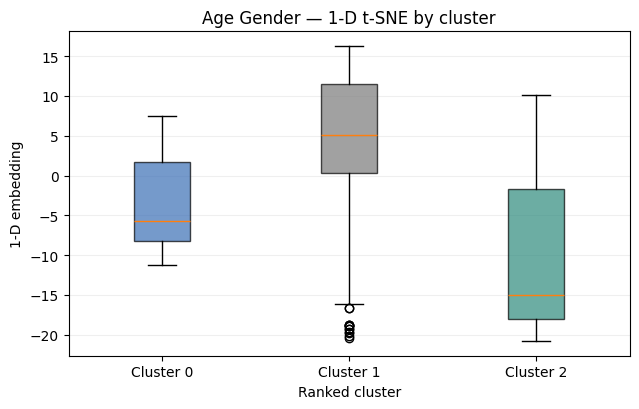

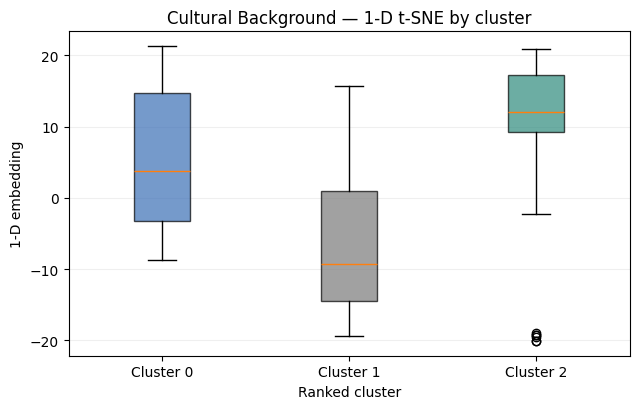

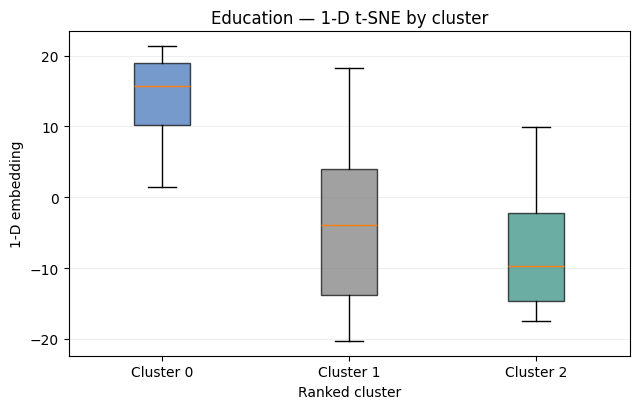

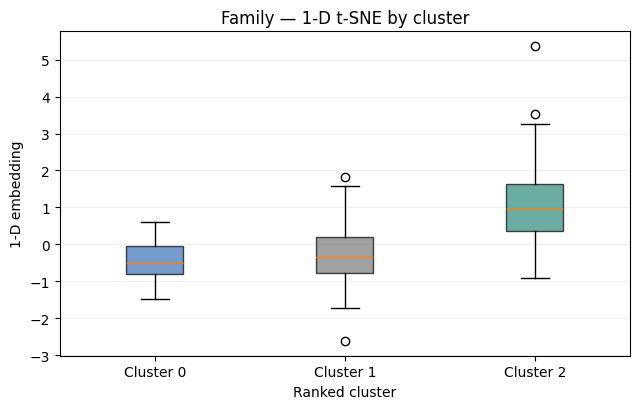

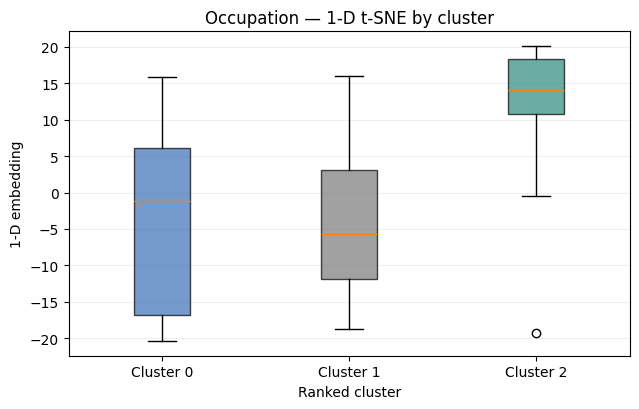

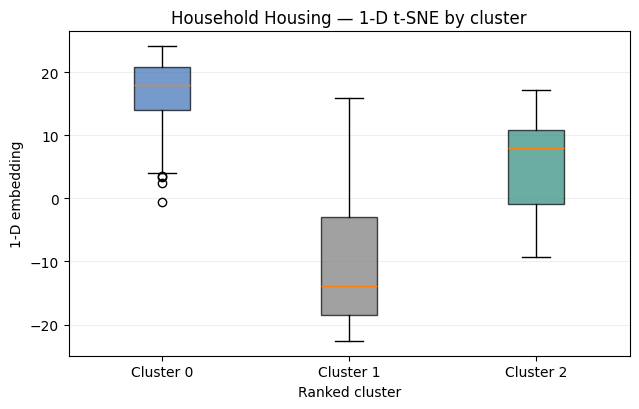

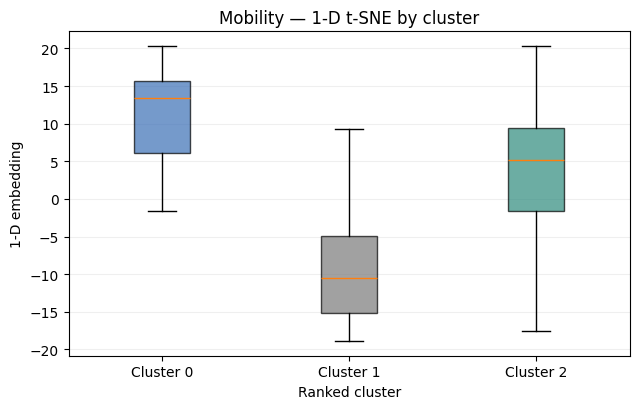

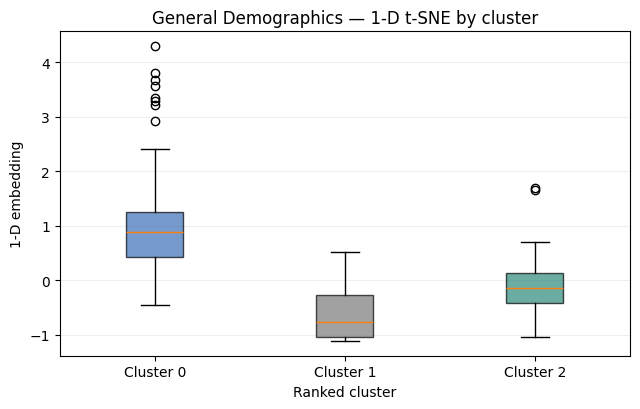

In [38]:
for category, retained in tsne_category_features.items():
    column = f"{category}_tsne_1d"

    if column not in tsne_embeddings.columns:
        continue

    groups = [
        tsne_embeddings.loc[
            tsne_embeddings["cluster"] == c,
            column
        ].to_numpy()
        for c in cluster_ids
    ]

    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    bp = ax.boxplot(
        groups,
        labels=[f"Cluster {c}" for c in cluster_ids],
        patch_artist=True
    )

    for patch, c in zip(bp["boxes"], cluster_ids):
        patch.set_facecolor(CLUSTER_COLORS[c])
        patch.set_alpha(0.7)

    ax.set_xlabel("Ranked cluster")
    ax.set_ylabel("1-D embedding")
    ax.set_title(
        f"{category.replace('_', ' ')} — 1-D t-SNE by cluster"
    )
    ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()

    tsne_path = os.path.join(
        figure_dir,
        f"tsne_{category.lower()}.png"
    )

    plt.savefig(
        tsne_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


## Step 38: Temporal pattern: mean daily cases per postcode by cluster

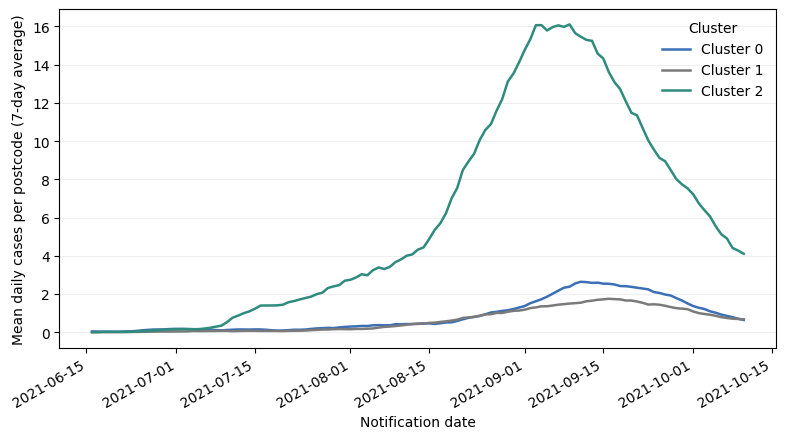

Saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures/cluster_temporal_cases_7day_average.png


In [39]:
# Link each postcode to its final ranked cluster
cluster_lookup = model_data[[
    "postcode",
    "cluster"
]].copy()

# Merge cluster membership with daily postcode-level COVID cases
cluster_daily_cases = daily_cases.merge(
    cluster_lookup,
    on="postcode",
    how="inner"
)

# Mean daily cases per postcode within each cluster
cluster_daily_summary = (
    cluster_daily_cases
    .groupby([
        "notification_date",
        "cluster"
    ])["new_cases"]
    .mean()
    .reset_index(
        name="mean_daily_cases"
    )
)

# 7-day rolling average within each cluster
cluster_daily_summary["mean_daily_cases_7d"] = (
    cluster_daily_summary
    .sort_values([
        "cluster",
        "notification_date"
    ])
    .groupby("cluster")["mean_daily_cases"]
    .transform(
        lambda s: s.rolling(
            7,
            min_periods=1
        ).mean()
    )
)

fig, ax = plt.subplots(
    figsize=(8.0, 4.5)
)

for cluster in sorted(
    cluster_daily_summary["cluster"].unique()
):
    d = cluster_daily_summary[
        cluster_daily_summary["cluster"] == cluster
    ]

    ax.plot(
        d["notification_date"],
        d["mean_daily_cases_7d"],
        label=f"Cluster {cluster}",
        color=CLUSTER_COLORS[cluster],
        linewidth=1.8
    )

ax.set_xlabel("Notification date")
ax.set_ylabel(
    "Mean daily cases per postcode (7-day average)"
)
ax.legend(
    title="Cluster",
    frameon=False
)
ax.grid(
    axis="y",
    alpha=0.2
)

fig.autofmt_xdate()
plt.tight_layout()

temporal_path = os.path.join(
    figure_dir,
    "cluster_temporal_cases_7day_average.png"
)

plt.savefig(
    temporal_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", temporal_path)


## Step 39: Geographic cluster and COVID-19 IR maps

Mapped POAs: 247
Missing cluster assignments: 0


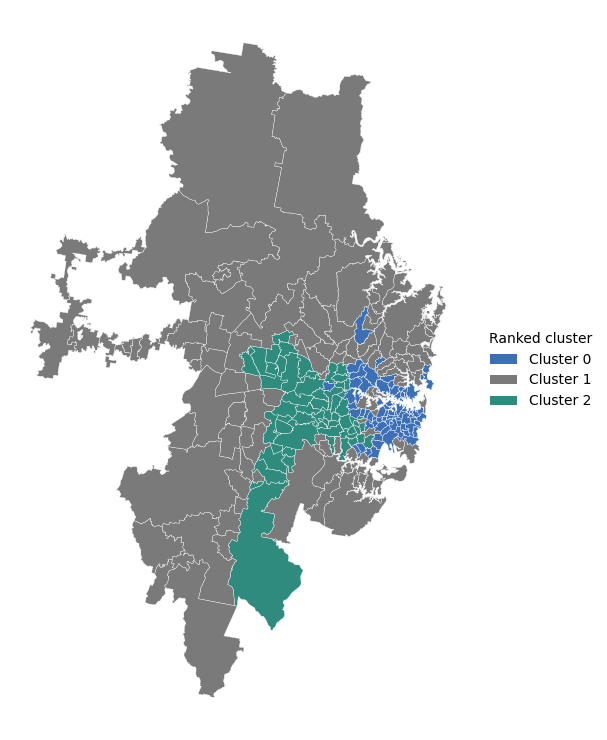

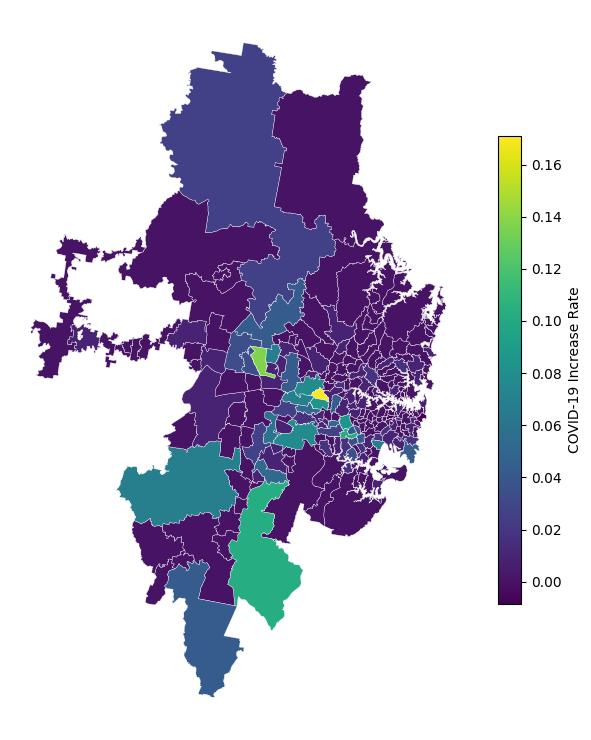

Saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures/greater_sydney_cluster_map.png
Saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures/greater_sydney_covid_ir_map.png


In [40]:
sydney_map = sydney_boundaries.merge(
    model_data[[
        "postcode",
        "cluster",
        "covid_IR",
        "covid_cases",
        "covid_cases_per_1000"
    ]],
    on="postcode",
    how="left"
)

print("Mapped POAs:", len(sydney_map))
print(
    "Missing cluster assignments:",
    sydney_map["cluster"].isna().sum()
)

# ------------------------------------------------------------
# Cluster map
# ------------------------------------------------------------

map_cluster_order = sorted(
    sydney_map["cluster"].dropna().astype(int).unique()
)

cluster_cmap = ListedColormap([
    CLUSTER_COLORS[c]
    for c in map_cluster_order
])

fig, ax = plt.subplots(
    figsize=(6.5, 7.5)
)

sydney_map.plot(
    column="cluster",
    categorical=True,
    cmap=cluster_cmap,
    edgecolor="white",
    linewidth=0.25,
    ax=ax
)

legend_handles = [
    Patch(
        facecolor=CLUSTER_COLORS[c],
        edgecolor="none",
        label=f"Cluster {c}"
    )
    for c in map_cluster_order
]

ax.legend(
    handles=legend_handles,
    title="Ranked cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.set_axis_off()

plt.tight_layout()

cluster_map_path = os.path.join(
    figure_dir,
    "greater_sydney_cluster_map.png"
)

plt.savefig(
    cluster_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# COVID-19 IR map
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.5, 7.5)
)

sydney_map.plot(
    column="covid_IR",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.25,
    ax=ax,
    legend_kwds={
        "label": "COVID-19 Increase Rate",
        "shrink": 0.65
    }
)

ax.set_axis_off()

plt.tight_layout()

ir_map_path = os.path.join(
    figure_dir,
    "greater_sydney_covid_ir_map.png"
)

plt.savefig(
    ir_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", cluster_map_path)
print("Saved:", ir_map_path)


## Step 40: Sensitivity analysis using k = 6
A six-cluster solution is fitted using the same 18 selected standardised features to mirror the number of clusters used in the original NYC study. This is a sensitivity analysis and does not replace the primary `k = 3` solution.


In [41]:
kmeans_6 = KMeans(
    n_clusters=6,
    random_state=RANDOM_STATE,
    n_init=20
)

sensitivity_6 = model_data[[
    "postcode", "covid_IR", "covid_cases", "covid_cases_per_1000"
]].copy()

sensitivity_6["raw_cluster_6"] = kmeans_6.fit_predict(X_selected)

cluster_6_ir = (
    sensitivity_6
    .groupby("raw_cluster_6")["covid_IR"]
    .mean()
    .sort_values()
)

cluster_6_mapping = {
    raw_cluster: rank
    for rank, raw_cluster in enumerate(cluster_6_ir.index)
}

sensitivity_6["cluster_6"] = sensitivity_6["raw_cluster_6"].map(cluster_6_mapping)

cluster_6_summary = (
    sensitivity_6
    .groupby("cluster_6")
    .agg(
        n_postcodes=("postcode", "count"),
        mean_covid_IR=("covid_IR", "mean"),
        median_covid_IR=("covid_IR", "median"),
        mean_cases=("covid_cases", "mean"),
        mean_cases_per_1000=("covid_cases_per_1000", "mean")
    )
    .round(4)
)

print("Silhouette at k=6:", float(k_diagnostics.loc[k_diagnostics["k"] == 6, "silhouette"].iloc[0]))
cluster_6_summary

Silhouette at k=6: 0.2316294972639102


,n_postcodes,mean_covid_IR,median_covid_IR,mean_cases,mean_cases_per_1000
cluster_6,,,,,
0,51,0.0015,0.0000,74.7059,4.3833
1,61,0.0018,0.0000,28.4590,2.2118
2,35,0.0085,0.0000,142.1143,6.3725
3,59,0.0125,0.0085,242.5085,9.7464
4,18,0.0133,0.0085,395.2778,13.9997
5,23,0.0431,0.0256,1021.0870,32.7422


## Step 41: Save final results and trained objects



In [42]:
# Tabular analysis outputs
lasso_results.to_csv(
    os.path.join(checkpoint_dir, "lasso_results.csv"),
    index=False
)

rrelieff_results.to_csv(
    os.path.join(checkpoint_dir, "rrelieff_results.csv"),
    index=False
)

k_diagnostics.to_csv(
    os.path.join(checkpoint_dir, "k_diagnostics.csv"),
    index=False
)

model_data.to_csv(
    os.path.join(checkpoint_dir, "sydney_model_results.csv"),
    index=False
)

cluster_summary.to_csv(
    os.path.join(checkpoint_dir, "cluster_summary.csv")
)

tsne_embeddings.to_csv(
    os.path.join(checkpoint_dir, "category_tsne_embeddings.csv"),
    index=False
)

cluster_daily_summary.to_csv(
    os.path.join(checkpoint_dir, "cluster_daily_summary.csv"),
    index=False
)

sensitivity_6.to_csv(
    os.path.join(checkpoint_dir, "k6_sensitivity_results.csv"),
    index=False
)

cluster_6_summary.to_csv(
    os.path.join(checkpoint_dir, "k6_cluster_summary.csv")
)

sydney_map.to_file(
    os.path.join(
        checkpoint_dir,
        "sydney_geographic_results.gpkg"
    ),
    driver="GPKG"
)

feature_dictionary = []

for category, cols in FEATURE_GROUPS.items():
    for col in cols:
        feature_dictionary.append({
            "category": category,
            "feature": col
        })

pd.DataFrame(
    feature_dictionary
).to_csv(
    os.path.join(
        checkpoint_dir,
        "feature_dictionary_28.csv"
    ),
    index=False
)

selected_features_by_domain.to_csv(
    os.path.join(
        checkpoint_dir,
        "selected_features_by_domain.csv"
    ),
    index=False
)

# Trained preprocessing / modelling objects
joblib.dump(
    scaler,
    os.path.join(
        model_dir,
        "standard_scaler.joblib"
    )
)

joblib.dump(
    lasso,
    os.path.join(
        model_dir,
        "lasso_cv.joblib"
    )
)

joblib.dump(
    kmeans,
    os.path.join(
        model_dir,
        f"kmeans_primary_k{PRIMARY_K}.joblib"
    )
)

pd.DataFrame({
    "selected_feature": selected_features
}).to_csv(
    os.path.join(
        model_dir,
        "selected_features.csv"
    ),
    index=False
)

print("Final tabular outputs saved to:", checkpoint_dir)
print("Trained objects saved to:", model_dir)
print("Figures saved to:", figure_dir)


Final tabular outputs saved to: /content/Data_Science_Reproduction_Part_B/results
Trained objects saved to: /content/Data_Science_Reproduction_Part_B/submission_outputs/models
Figures saved to: /content/Data_Science_Reproduction_Part_B/submission_outputs/figures


## Step 42: Create final README / run instructions


In [45]:
cluster_summary_text = cluster_summary.to_string()

readme_text = f"""Data Science Reproduction Part B
===================================

PURPOSE
-------
Methodological reproduction of Khmaissia et al. (2020) using Greater
Sydney Postal Areas (POAs), ABS 2021 Census data and NSW Health
COVID-19 case data.

PUBLIC INPUT DATA
-----------------
1. NSW Health COVID-19 cases by location
   Landing page:
   https://data.nsw.gov.au/data/dataset/covid-19-cases-by-location

   File used:
   confirmed_cases_table1_location.csv

2. ABS 2021 Census General Community Profile
   Geography: Postal Areas (POA)
   State: New South Wales
   Header: short-header

   Landing page:
   https://www.abs.gov.au/census/find-census-data/datapacks

   File used:
   2021_GCP_POA_for_NSW_short-header.zip

3. ABS 2021 Postal Area boundaries
   GDA2020 Shapefile

   Landing page:
   https://www.abs.gov.au/statistics/standards/
   australian-statistical-geography-standard-asgs/
   edition-3-july-2021-june-2026/access-and-downloads/
   digital-boundary-files

   File used:
   POA_2021_AUST_GDA2020_SHP.zip

HOW TO RUN
----------
1. Open Data_Science_Reproduction_Part_B.ipynb in Google Colab.
2. Run all cells sequentially from Step 1 to the end.
3. Step 2 attempts to download all three source datasets automatically.
4. If an automatic download is blocked, upload the three files when
   prompted by Step 2.
5. Continue running all cells in order.
6. Results, figures, trained objects and this README are written under:
   /content/Data_Science_Reproduction_Part_B/

STUDY DESIGN
------------
Study area: Greater Sydney
Final cohort: {len(model_data)} POAs
Study window: {start_date} to {end_date} inclusive ({n_days} days)

ABS Postal Areas (POAs) are used as an approximation of postcode
boundaries to link Census and NSW Health postcode-level information.

CORE MODELLING PIPELINE
-----------------------
247 Greater Sydney POAs
-> 28 predefined candidate predictors
-> z-score standardisation using StandardScaler
-> LASSO + RReliefF feature selection
-> union of selected features
-> K-means on the selected standardised features
-> primary k = {PRIMARY_K}
-> rank cluster labels by mean COVID-19 Increase Rate (IR)
-> cluster feature-profile heatmap using mean standardised values
-> category-level 1-D t-SNE after clustering for interpretation
-> temporal and geographic analyses
-> k = 6 sensitivity analysis

FEATURE SELECTION
-----------------
LASSO:
- 5-fold cross-validation
- alpha selected by LassoCV: {lasso.alpha_:.12g}
- features retained when coefficient is non-zero
- number retained: {len(lasso_selected)}

RReliefF:
- source repository: https://github.com/AmritSe/RReliefF
- source file:
  https://raw.githubusercontent.com/AmritSe/RReliefF/master/relieff.py
- updates = "all"
- k = 10
- sigma = 30
- selection rule: weight > 0
- number retained: {len(rrelieff_selected)}

Overlap between LASSO and RReliefF: {len(overlap)}
Final union used for K-means: {len(selected_features)}

CLUSTER SELECTION
-----------------
Candidate k values: 2 to 10
Highest silhouette k: {best_silhouette_k}
Highest silhouette score: {best_silhouette_score:.4f}
Primary k: {PRIMARY_K}
Primary-k silhouette score: {primary_silhouette:.4f}

The silhouette coefficient is highest at k = 2. Inspection of the
elbow curve indicates diminishing improvements in inertia after
approximately k = 3. Because the silhouette score for k = 3 remains
close to the maximum and the elbow supports a three-cluster solution,
k = 3 is retained for the primary analysis.

PRIMARY CLUSTER SUMMARY
-----------------------
{cluster_summary_text}

EXPLORATORY IR COMPARISONS
--------------------------
One-way ANOVA:
F = {anova_result.statistic:.6f}
p = {anova_result.pvalue:.6g}

Kruskal-Wallis:
H = {kruskal_result.statistic:.6f}
p = {kruskal_result.pvalue:.6g}

These comparisons are exploratory rather than independent validation
because COVID-19 IR is used during supervised feature selection and
later to rank the cluster labels.

IMPORTANT IMPLEMENTATION NOTES
------------------------------
- COVID-19 IR is not an input to K-means.
- K-means is fitted directly to the selected standardised predictors.
- IR is used for supervised feature selection and post-clustering
  ranking of cluster labels.
- The cluster profile heatmap displays mean z-scores for the 18 selected
  features within each primary cluster and is used to interpret the
  characteristics that distinguish the clusters.
- Category-level t-SNE is performed after clustering and is used only
  for interpretation.
- t-SNE coordinate signs and magnitudes should not be interpreted as
  original feature weights or effect directions.
- Raw population is not a K-means predictor. It is used to calculate
  cases per 1,000 population and population density.
- The external RReliefF implementation must be cited because borrowed
  source code is used.

OUTPUTS
-------
Results:
{checkpoint_dir}

Figures:
{figure_dir}

Trained objects:
{model_dir}
"""

readme_path = os.path.join(
    output_dir,
    "README.txt"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(readme_text)

print("README saved:", readme_path)


README saved: /content/Data_Science_Reproduction_Part_B/submission_outputs/README.txt


## Step 43: Package outputs into one ZIP file

import os
import shutil
from google.colab import files

zip_base = "/content/Data_Science_Reproduction_Part_B_outputs"

# Create ZIP from the full project folder
zip_path = shutil.make_archive
    (zip_base,
    "zip",
    root_dir="/content/Data_Science_Reproduction_Part_B")

print("Submission package created:")
print(zip_path)

# Download the ZIP
files.download(zip_path)

In [46]:
# Final step — Package submission outputs into one ZIP file

import os
import shutil
from google.colab import files

zip_base = "/content/Data_Science_Reproduction_Part_B_outputs"

# Create ZIP from the full project folder
zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir="/content/Data_Science_Reproduction_Part_B"
)

print("Submission package created:")
print(zip_path)

# Download the ZIP
files.download(zip_path)


Submission package created:
/content/Data_Science_Reproduction_Part_B_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>